# Shapley Analysis

In this notebook, we analyse the generated Shapley values for models trained using RIGR and Native featurizers. For K-Means and random split, we have a five-ensemble model. The final reported values are averaged over the five models.

An example script for generating the Shapley values for `Native` models (full feature set) can be found [here](https://github.com/akshatzalte/chemprop/tree/rigr_home/notebooks/shapley_generation_native.py). The method behind this code is implemented in [Chemprop v2](https://github.com/chemprop/chemprop) as an example [notebook](https://github.com/chemprop/chemprop/blob/main/examples/shapley_value_with_customized_featurizers.ipynb). For `RIGR` models (smaller feature set), the modified Shapley script can be found [here](https://github.com/akshatzalte/chemprop/tree/rigr_home/notebooks/shapley_generation_rigr.py).

In [1]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns

rc = mpl.rc_params_from_file("/home/akshatz/.config/matplotlib/matplotlibrc", use_default_template=False)
sns.set_theme(style="white", rc=rc)
mpl.rcParams.update(rc)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
my_blue = "#83CDE6"
my_red = "#A4394A"

In [3]:
def create_dataframe(data_dir, num_models=5, num_molecules=5000):
  """Creates a DataFrame from the given data directory.

  Args:
    data_dir: The root directory containing the model folders.

  Returns:
    A pandas DataFrame with columns 'Model', 'Feature', and 'Norm Values'.
  """

  data = []
  for model_idx in range(num_models):
    model_dirs = list(Path(data_dir).glob(f"*model_{model_idx}"))
    if not model_dirs:
      continue
    model_path = model_dirs[0]  # Assuming only one matching directory per model index
    
    for file_idx in range(num_molecules):
      file_path = model_path / f"{file_idx}_values.npy"
      norm_values = abs(np.load(file_path))
      norm_values = norm_values[0]
      for feature_idx in range(len(norm_values)):
        data.append([file_idx, model_idx, feature_idx, norm_values[feature_idx]])

  df = pd.DataFrame(data, columns=['molecule', 'model', 'feature', 'norm_value'])
  return df

## K-Means split

In [4]:
df1 = create_dataframe('k_means/rigr', 5, 4794)

feature_names = ["atomic no.", "degree", "no. of H", "atomic mass", "ring"]
model_names = ["Model 0", "Model 1", "Model 2", "Model 3", "Model 4"]
df1['Initialization'] = df1['model'].map(lambda x: model_names[x])
df1['feature_name'] = df1['feature'].map(lambda x: feature_names[x])

df1_avg = df1.groupby(['molecule', 'feature', 'model']).agg({'norm_value': 'mean'}).reset_index()
df1_avg

,molecule,feature,model,norm_value
0,0,0,0,42.395056
1,0,0,1,66.638820
2,0,0,2,31.916833
3,0,0,3,77.058589
4,0,0,4,51.645401
...,...,...,...,...
119845,4793,4,0,0.824421
119846,4793,4,1,8.701832
119847,4793,4,2,0.336714
119848,4793,4,3,27.959100


In [5]:
feature_stats_rigr = df1_avg.groupby(['feature', 'model']).agg(
    avg_norm_value=('norm_value', 'mean'),
).reset_index()
feature_stats_rigr['feature_name'] = feature_stats_rigr['feature'].map(lambda x: feature_names[x])
# display(feature_stats_rigr)
feature_stats_rigr_1 = feature_stats_rigr.groupby('feature').agg(
    avg_norm_value=('avg_norm_value', 'mean'),
    std_norm_value=('avg_norm_value', lambda x: x.std(ddof=0))
).reset_index()
feature_stats_rigr_1['feature_name'] = feature_stats_rigr_1['feature'].map(lambda x: feature_names[x])
# feature_stats_rigr_1

In [6]:
df2 = create_dataframe('k_means/native', 5, 4794)
feature_names = ["atomic no.", "degree", "formal charge", "chirality", "no. of H", "hybridization", "aromaticity", "atomic mass", "bond type", "conjugation", "ring", "stereo"]
model_names = ["Model 0", "Model 1", "Model 2", "Model 3", "Model 4"]
df2['Initialization'] = df2['model'].map(lambda x: model_names[x])
df2['feature_name'] = df2['feature'].map(lambda x: feature_names[x])
df2_avg = df2.groupby(['molecule', 'feature', 'model']).agg({'norm_value': 'mean'}).reset_index()
df2_avg

,molecule,feature,model,norm_value
0,0,0,0,34.701449
1,0,0,1,40.030502
2,0,0,2,41.788406
3,0,0,3,33.961799
4,0,0,4,37.512304
...,...,...,...,...
287635,4793,11,0,11.041389
287636,4793,11,1,7.562688
287637,4793,11,2,4.745897
287638,4793,11,3,2.488295


In [7]:
feature_stats_baseline = df2_avg.groupby(['feature', 'model']).agg(
    avg_norm_value=('norm_value', 'mean'),
).reset_index()

feature_stats_baseline['feature_name'] = feature_stats_baseline['feature'].map(lambda x: feature_names[x])
# display(feature_stats_baseline)
feature_stats_baseline_1 = feature_stats_baseline.groupby('feature').agg(
    avg_norm_value=('avg_norm_value', 'mean'),
    std_norm_value=('avg_norm_value', lambda x: x.std(ddof=0))
).reset_index()
feature_stats_baseline_1['feature_name'] = feature_stats_baseline_1['feature'].map(lambda x: feature_names[x])
# feature_stats_baseline_1

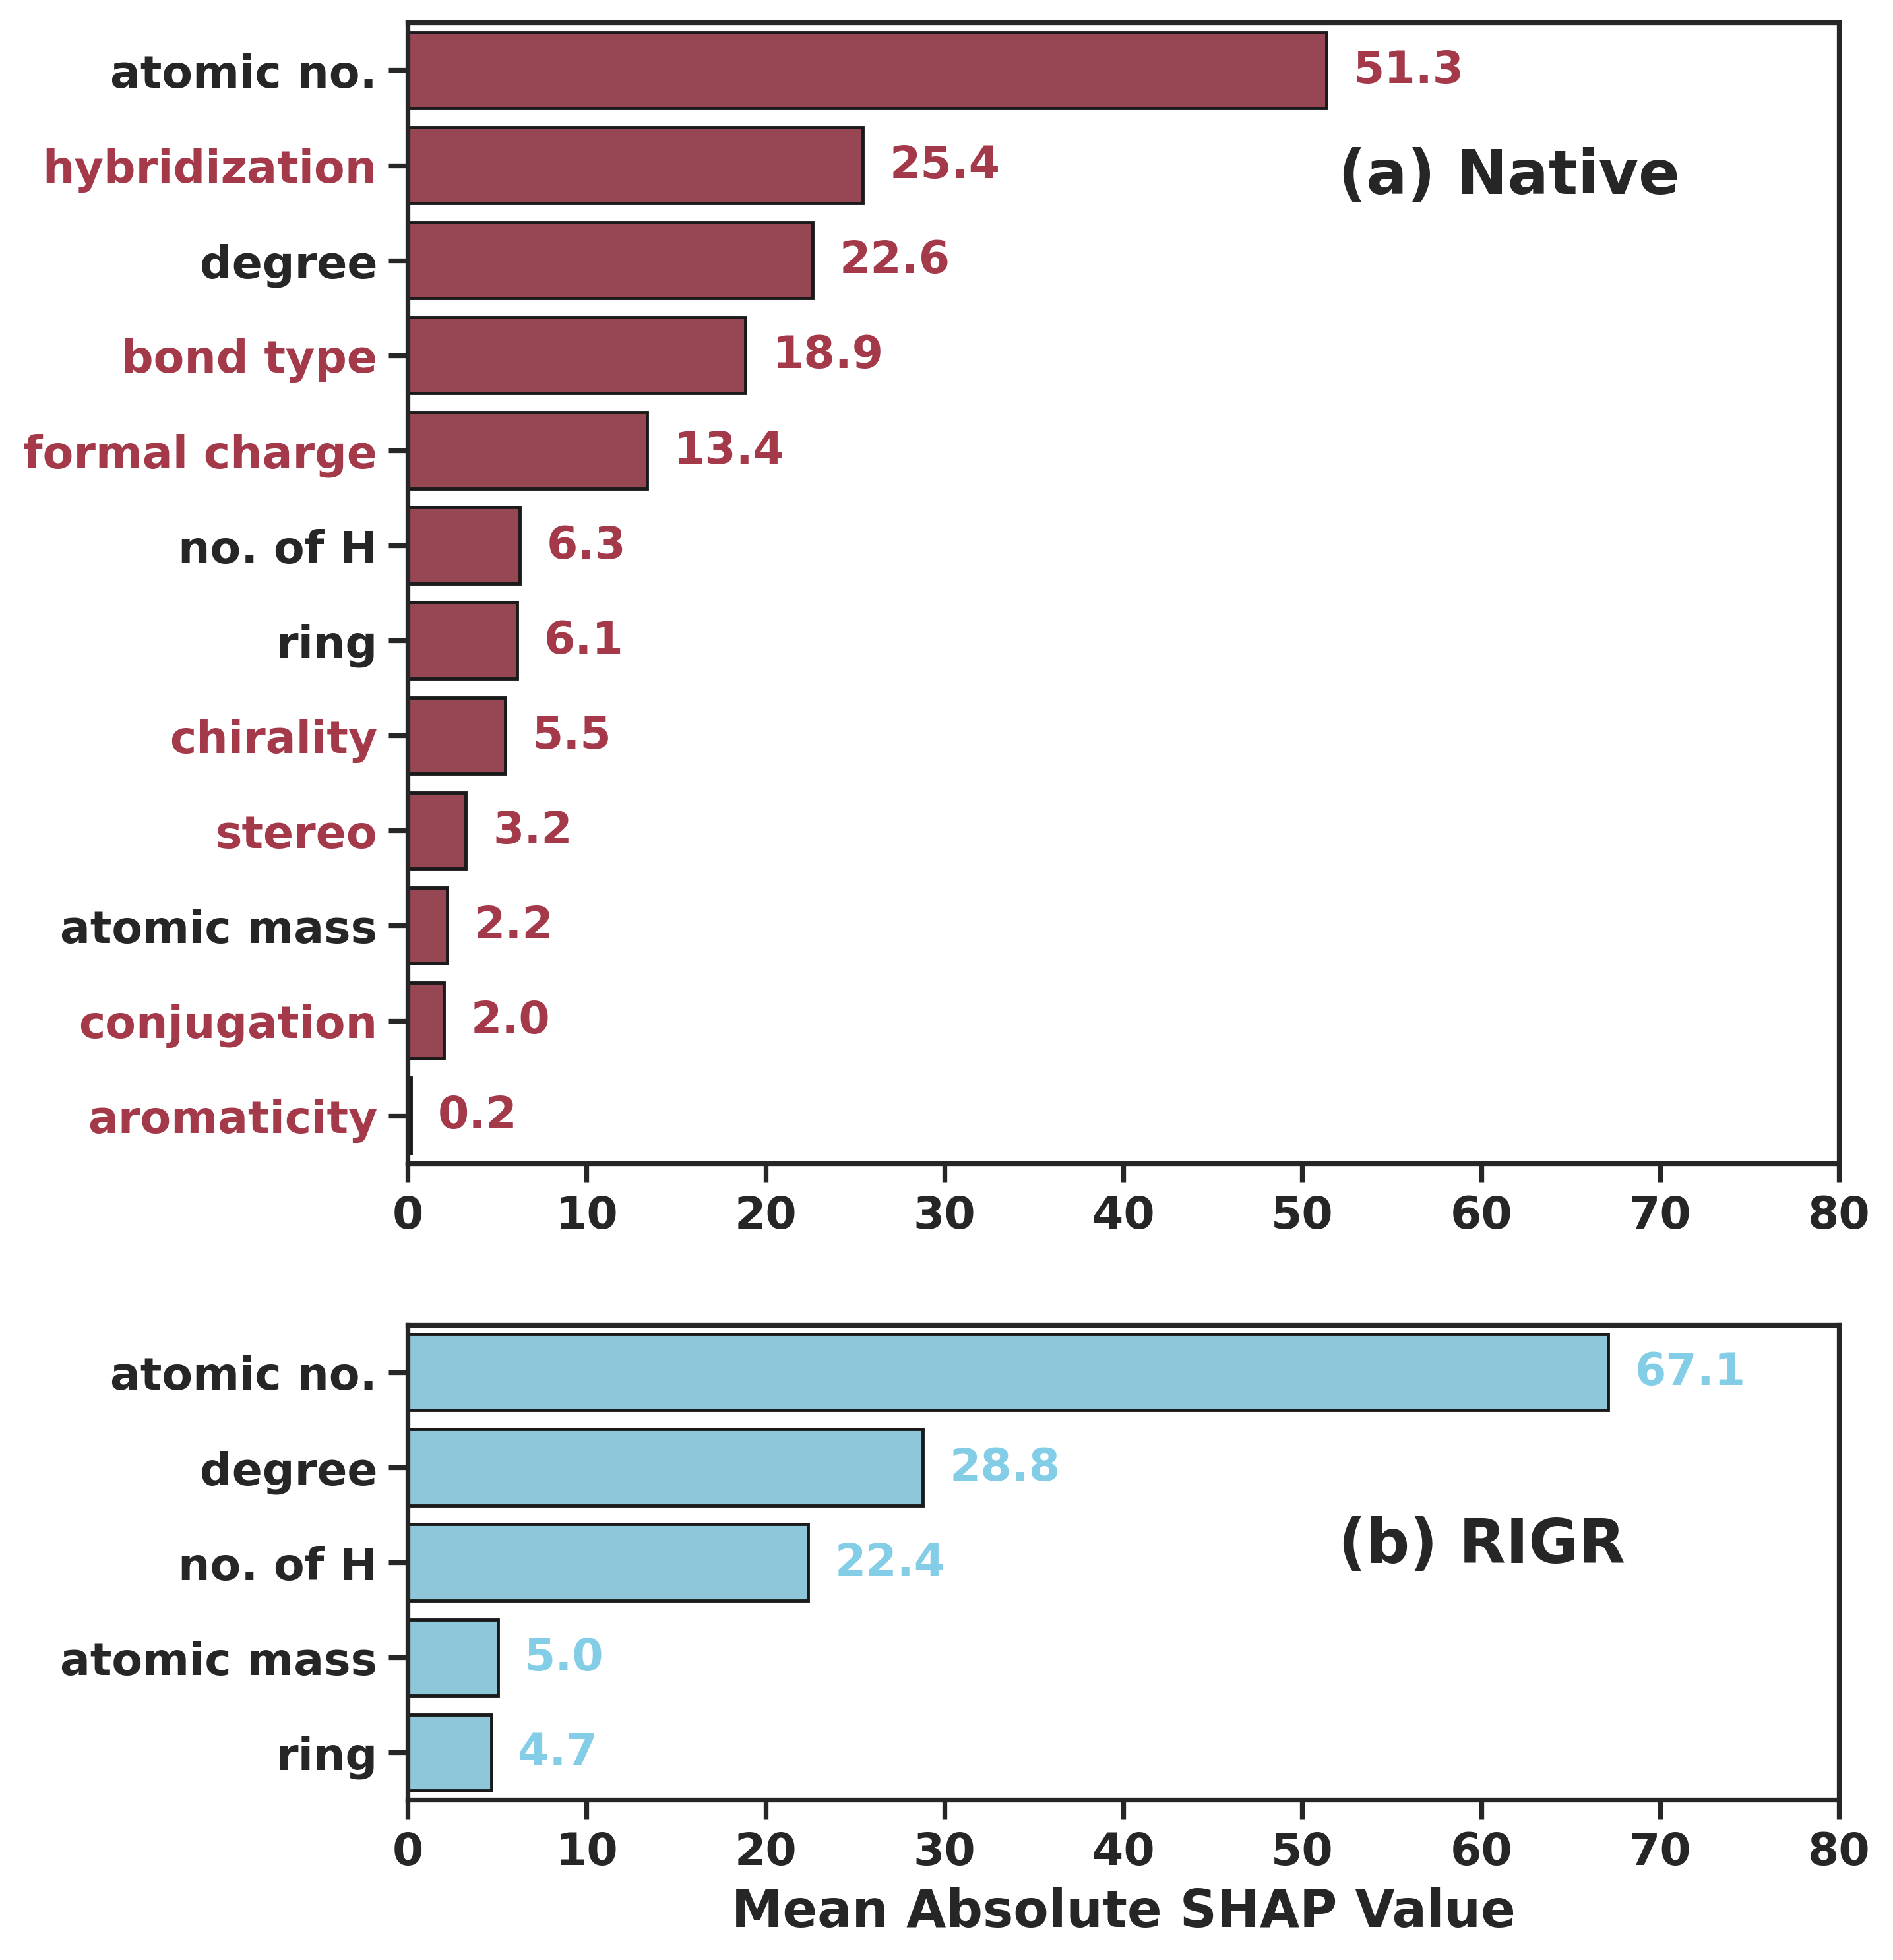

In [8]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 10), dpi=350)
gs = gridspec.GridSpec(2, 1, height_ratios=[12, 5])  # Change the width ratios as needed

# Create subplots and assign them to the grid spec
ax2 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

sorted_inds = np.argsort(np.abs(feature_stats_rigr_1['avg_norm_value']))[::-1]
xs = feature_stats_rigr_1['avg_norm_value'].values[sorted_inds]
xerrs = feature_stats_rigr_1['std_norm_value'].values[sorted_inds]
ys = feature_stats_rigr_1['feature_name'].values[sorted_inds]

sns.barplot(y=ys, x=xs, orient='h', color=my_blue, alpha=1, ax=ax1)

for i, (value, name) in enumerate(zip(xs, ys)):
    ax1.text(value + 1.5, i, f'{value:.1f}', va='center', color=my_blue)
ax1.set_xlabel("Mean Absolute SHAP Value")
ax1.set_xlim([0, 80])
ax1.text(0.65, 0.5, "(b) RIGR", transform=ax1.transAxes, fontsize=19)

sorted_inds = np.argsort(np.abs(feature_stats_baseline_1['avg_norm_value']))[::-1]
xs = feature_stats_baseline_1['avg_norm_value'].values[sorted_inds]
xerrs = feature_stats_baseline_1['std_norm_value'].values[sorted_inds]
ys = feature_stats_baseline_1['feature_name'].values[sorted_inds]


sns.barplot(y=ys, x=xs, orient='h', color=my_red, alpha=1, ax=ax2)

for i, (value, name) in enumerate(zip(xs, ys)):
    ax2.text(value + 1.5, i, f'{value:.1f}', va='center', color=my_red)
ax2.set_xlim([0, 80])
ax2.set_xlabel("")
ax2.text(0.65, 0.85, "(a) Native", transform=ax2.transAxes, fontsize=19)
yticks = ax2.get_yticklabels()

tick_labels_to_red = ["hybridization", "bond type", "formal charge", "chirality", "stereo", "conjugation", "aromaticity"] 
for tick in yticks:
    if tick.get_text() in tick_labels_to_red:
        tick.set_color(my_red)

# fig.tight_layout()
# fig.savefig("/home/akshatz/bond_order_free/figures/shapley_k_means.pdf", bbox_inches="tight")

## Random split

In [9]:
df1 = create_dataframe('random/rigr', 5, 5000)

feature_names = ["atomic no.", "degree", "no. of H", "atomic mass", "ring"]
model_names = ["Model 0", "Model 1", "Model 2", "Model 3", "Model 4"]
df1['Initialization'] = df1['model'].map(lambda x: model_names[x])
df1['feature_name'] = df1['feature'].map(lambda x: feature_names[x])

df1_avg = df1.groupby(['molecule', 'feature', 'model']).agg({'norm_value': 'mean'}).reset_index()
df1_avg

,molecule,feature,model,norm_value
0,0,0,0,75.061761
1,0,0,1,101.587999
2,0,0,2,120.075658
3,0,0,3,106.914643
4,0,0,4,147.728622
...,...,...,...,...
124995,4999,4,0,25.865821
124996,4999,4,1,2.493144
124997,4999,4,2,21.698635
124998,4999,4,3,22.455476


In [10]:
feature_stats_rigr = df1_avg.groupby(['feature', 'model']).agg(
    avg_norm_value=('norm_value', 'mean'),
).reset_index()
feature_stats_rigr['feature_name'] = feature_stats_rigr['feature'].map(lambda x: feature_names[x])
# display(feature_stats_rigr)
feature_stats_rigr_1 = feature_stats_rigr.groupby('feature').agg(
    avg_norm_value=('avg_norm_value', 'mean'),
    std_norm_value=('avg_norm_value', lambda x: x.std(ddof=0))
).reset_index()
feature_stats_rigr_1['feature_name'] = feature_stats_rigr_1['feature'].map(lambda x: feature_names[x])
# feature_stats_rigr_1

In [11]:
df2 = create_dataframe('random/native', 5, 5000)
feature_names = ["atomic no.", "degree", "formal charge", "chirality", "no. of H", "hybridization", "aromaticity", "atomic mass", "bond type", "conjugation", "ring", "stereo"]
model_names = ["Model 0", "Model 1", "Model 2", "Model 3", "Model 4"]
df2['Initialization'] = df2['model'].map(lambda x: model_names[x])
df2['feature_name'] = df2['feature'].map(lambda x: feature_names[x])
df2_avg = df2.groupby(['molecule', 'feature', 'model']).agg({'norm_value': 'mean'}).reset_index()
df2_avg

,molecule,feature,model,norm_value
0,0,0,0,83.926442
1,0,0,1,60.044409
2,0,0,2,72.454049
3,0,0,3,82.038924
4,0,0,4,84.980386
...,...,...,...,...
299995,4999,11,0,7.622283
299996,4999,11,1,6.585316
299997,4999,11,2,16.056643
299998,4999,11,3,11.211782


In [12]:
feature_stats_baseline = df2_avg.groupby(['feature', 'model']).agg(
    avg_norm_value=('norm_value', 'mean'),
).reset_index()

feature_stats_baseline['feature_name'] = feature_stats_baseline['feature'].map(lambda x: feature_names[x])
# display(feature_stats_baseline)
feature_stats_baseline_1 = feature_stats_baseline.groupby('feature').agg(
    avg_norm_value=('avg_norm_value', 'mean'),
    std_norm_value=('avg_norm_value', lambda x: x.std(ddof=0))
).reset_index()
feature_stats_baseline_1['feature_name'] = feature_stats_baseline_1['feature'].map(lambda x: feature_names[x])
# feature_stats_baseline_1

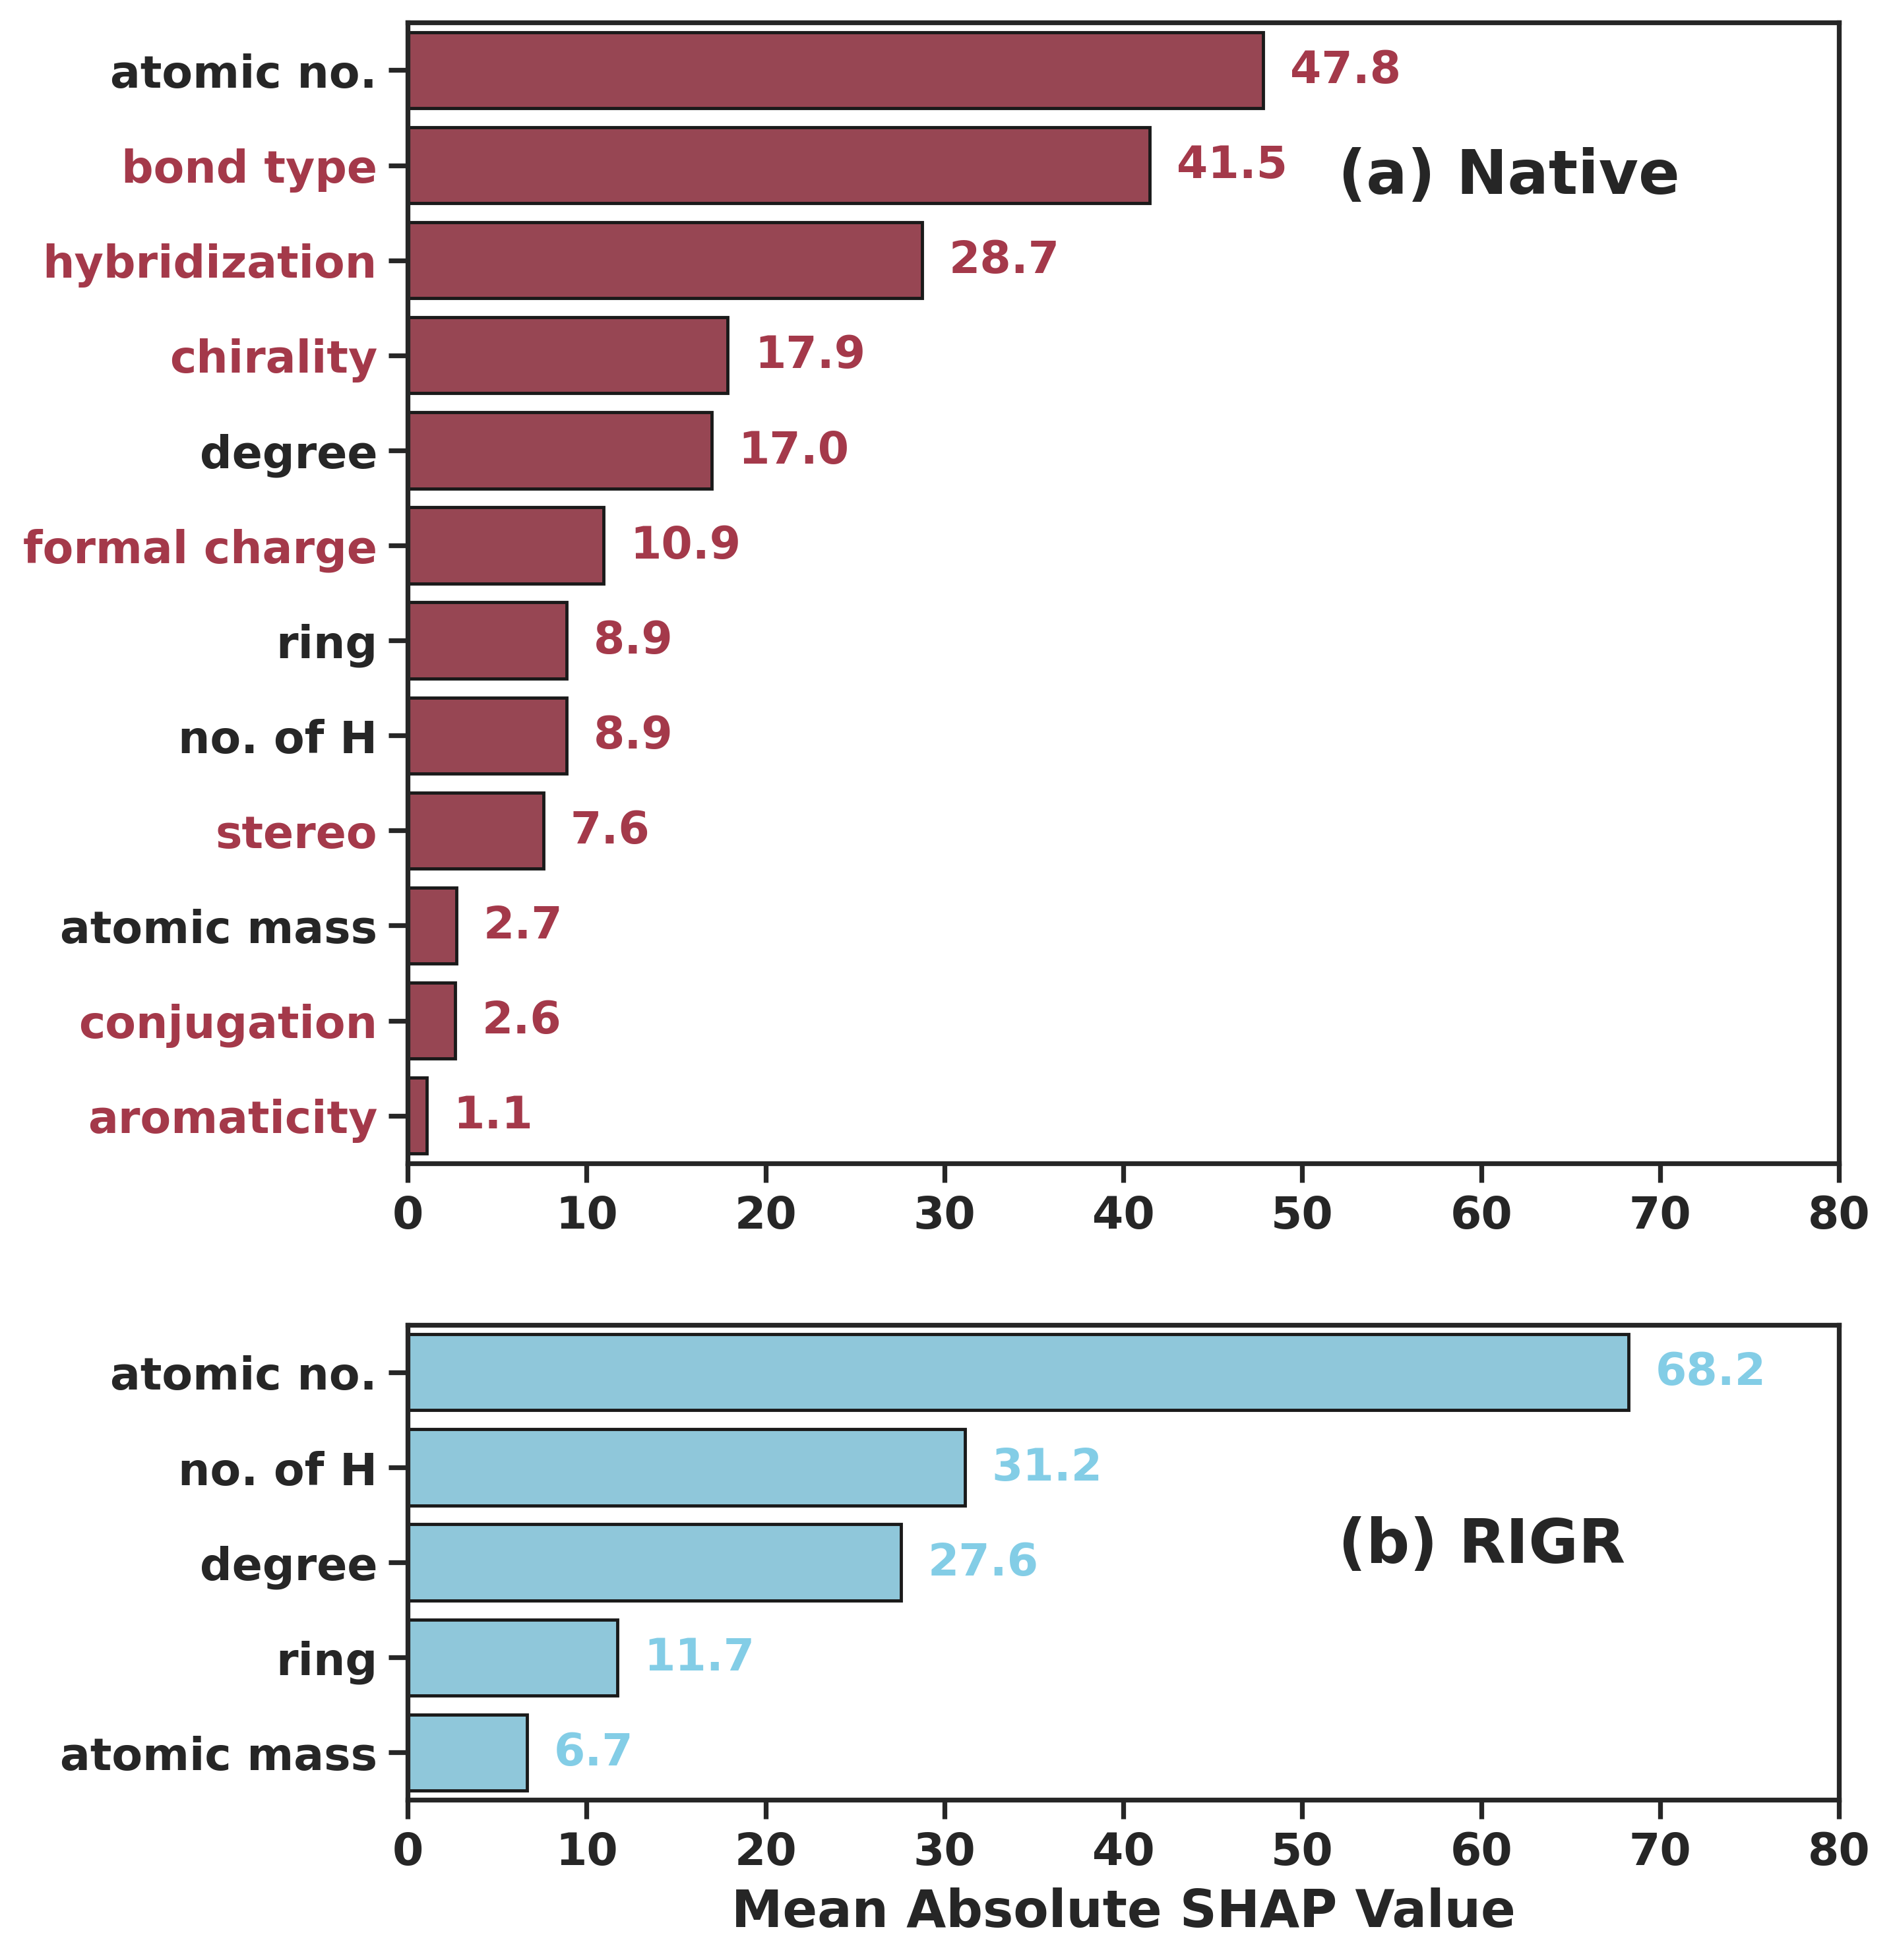

In [13]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 10), dpi=350)
gs = gridspec.GridSpec(2, 1, height_ratios=[12, 5])  # Change the width ratios as needed

# Create subplots and assign them to the grid spec
ax2 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

sorted_inds = np.argsort(np.abs(feature_stats_rigr_1['avg_norm_value']))[::-1]
xs = feature_stats_rigr_1['avg_norm_value'].values[sorted_inds]
xerrs = feature_stats_rigr_1['std_norm_value'].values[sorted_inds]
ys = feature_stats_rigr_1['feature_name'].values[sorted_inds]

sns.barplot(y=ys, x=xs, orient='h', color=my_blue, alpha=1, ax=ax1)

for i, (value, name) in enumerate(zip(xs, ys)):
    ax1.text(value + 1.5, i, f'{value:.1f}', va='center', color=my_blue)
ax1.set_xlabel("Mean Absolute SHAP Value")
ax1.set_xlim([0, 80])
ax1.text(0.65, 0.5, "(b) RIGR", transform=ax1.transAxes, fontsize=19)

sorted_inds = np.argsort(np.abs(feature_stats_baseline_1['avg_norm_value']))[::-1]
xs = feature_stats_baseline_1['avg_norm_value'].values[sorted_inds]
xerrs = feature_stats_baseline_1['std_norm_value'].values[sorted_inds]
ys = feature_stats_baseline_1['feature_name'].values[sorted_inds]

sns.barplot(y=ys, x=xs, orient='h', color=my_red, alpha=1, ax=ax2)

for i, (value, name) in enumerate(zip(xs, ys)):
    ax2.text(value + 1.5, i, f'{value:.1f}', va='center', color=my_red)
ax2.set_xlim([0, 80])
ax2.set_xlabel("")
ax2.text(0.65, 0.85, "(a) Native", transform=ax2.transAxes, fontsize=19)
yticks = ax2.get_yticklabels()

tick_labels_to_red = ["hybridization", "bond type", "formal charge", "chirality", "stereo", "conjugation", "aromaticity"] 
for tick in yticks:
    if tick.get_text() in tick_labels_to_red:
        tick.set_color(my_red)

# fig.tight_layout()
# fig.savefig("/home/akshatz/bond_order_free/figures_si/shapley_random.pdf", bbox_inches="tight")